# Creating a minimal Neural Network for classification

Note: Content adapted from: https://cs231n.github.io/


In this section we’ll walk through a complete implementation of a toy Neural Network in 2 dimensions. We’ll first implement a simple linear classifier and then extend the code to a 2-layer Neural Network. As we’ll see, this extension is surprisingly simple and very few changes are necessary.

In [10]:
# A bit of setup
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generating some data
Lets generate a classification dataset that is not easily linearly separable. Our favorite example is the spiral dataset, which can be generated as follows:

Text(0.5, 1.0, 'Spiral Dataset - 3 Classes')

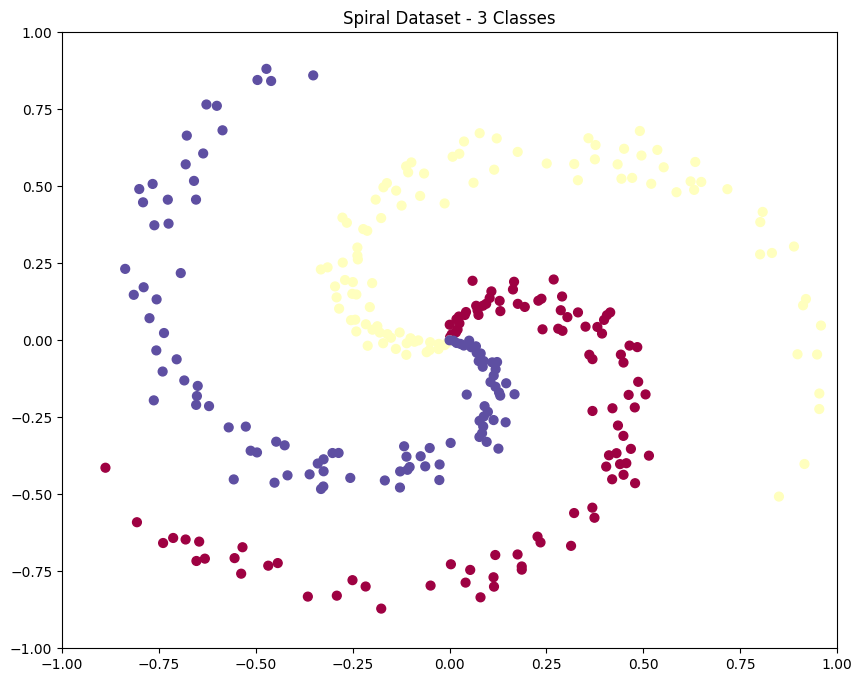

In [11]:
np.random.seed(0)
N = 100 # number of points per class
D = 2 # dimensionality (2D data for visualization)
K = 3 # number of classes
X = np.zeros((N*K, D))  # Data matrix: [300 x 2]
y = np.zeros(N*K, dtype='uint8')  # Class labels: [300]

# Generate spiral data for each class
for j in range(K):
    ix = range(N*j, N*(j+1))  # Indices for current class
    r = np.linspace(0.0, 1, N)  # Radius increases from 0 to 1
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2  # Theta angle with noise
    # Convert polar coordinates (r, theta) to Cartesian (x, y)
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]  # np.c_ concatenates columns side-by-side
    y[ix] = j  # Assign class label

fig = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.title('Spiral Dataset - 3 Classes')
#fig.savefig('spiral_raw.png')

The toy spiral data consists of three classes (blue, red, yellow) that are not linearly separable.

Normally we would want to preprocess the dataset so that each feature has zero mean and unit standard deviation, but in this case the features are already in a nice range from -1 to 1, so we skip this step.

## Training a Softmax Linear Classifier

We will use the Softmax activation function ($\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$) to convert the classifier output into probabilities and the [Cross-Entropy Loss](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e) ($L(x,y) = -\sum_{j} y_j \log p(c_j|x)$) to calculate the loss for a given set of weights W.

In [12]:
# Numpy version of Softmax function
def softmax_numpy(scores):
    """
    Convert class scores to probabilities using softmax.
    
    Parameters:
        scores: array of shape [N x K] where N is number of examples, K is number of classes
    Returns:
        probs: array of shape [N x K] with probabilities for each class
    """
    return np.exp(scores) / np.sum(np.exp(scores), axis=1, keepdims=True)  # [N x K]

# Calculate average cross-entropy loss
def cross_entropy_loss(probs, y):
    """
    Compute the cross-entropy loss.
    
    Parameters:
        probs: predicted probabilities of shape [N x K]
        y: true class labels of shape [N]
    Returns:
        loss: scalar value representing average loss
    """
    num_examples = probs.shape[0]
    correct_log_probs = -np.log(probs[range(num_examples), y])
    loss = np.sum(correct_log_probs) / num_examples
    return loss

**Softmax Activation Function**: For a given class score vector `z`, the softmax function calculates the probability `p_i` for each class `i` as follows:

``p_i = exp(z_i) / Σ_j exp(z_j)``

**Cross-Entropy Loss**: The cross-entropy loss for a single example with true label `y` and predicted probabilities `p` is given by:

``L = -log(p_y)``

Now, we want to compute the derivative of the loss L with respect to the softmax input (class scores) z. Let's denote this derivative as dL/dz. For simplicity, let's focus on the derivative of the loss with respect to a single class score z_i:

- If i is not the true class label (i ≠ y), then the derivative dL/dz_i is equal to the softmax probability p_i for that class.

```
dL/dz_i = d(-log(p_y))/dz_i = - (1/p_y) * dp_y/dz_i
        = - (1/p_y) * (-p_y * p_i)
        = p_i
```
Therefore we set: `grad_scores = probs`

- If i is the true class label (i = y), then the derivative dL/dz_i is equal to p_i - 1.

```
dL/dz_i = d(-log(p_y))/dz_i = - (1/p_y) * dp_y/dz_i
        = - (1/p_y) * (p_y * (1 - p_y))
        = p_y - 1
```

 Therefore we set: `grad_scores[range(num_examples),y] -= 1`

- Finally, we divide each element in the grad_scores matrix by the total number of examples (N). This step is necessary because we are computing the average gradient across all examples, as we used the average cross-entropy loss in the loss calculation. `grad_scores /= num_examples`


In [13]:
# Train a Linear Classifier

# Initialize parameters randomly
W = 0.01 * np.random.randn(D, K)  # Weight matrix [2 x 3]
b = np.zeros((1, K))              # Bias vector [1 x 3]

# Hyperparameters
step_size = 1e-0  # Learning rate
num_iterations = 200

# Gradient descent loop
num_examples = X.shape[0]  # N = 300
for i in range(num_iterations):

    # Forward pass: compute class scores [N x K]
    scores = np.dot(X, W) + b 

    # Compute the class probabilities using Softmax activation [N x K]
    probs = softmax_numpy(scores)

    # Compute the loss: average cross-entropy loss (scalar)
    loss = cross_entropy_loss(probs, y)
    
    if i % 10 == 0:
        print("iteration {:d}: loss {:f}".format(i, loss))

    # Backward pass: compute gradient of loss with respect to scores [N x K]
    grad_scores = probs.copy()                    # Start with probabilities
    grad_scores[range(num_examples), y] -= 1      # Subtract 1 from the correct class
    grad_scores /= num_examples                   # Average over all examples

    # Backpropagate the gradient to the parameters (W, b)
    grad_W = np.dot(X.T, grad_scores)             # [D x N] * [N x K] = [D x K]
    grad_b = np.sum(grad_scores, axis=0, keepdims=True)  # [1 x K]

    # Perform parameter update (gradient descent)
    W += -step_size * grad_W
    b += -step_size * grad_b

iteration 0: loss 1.096919
iteration 10: loss 0.915808
iteration 20: loss 0.847970
iteration 30: loss 0.817109
iteration 40: loss 0.801059
iteration 50: loss 0.791931
iteration 60: loss 0.786406
iteration 70: loss 0.782907
iteration 80: loss 0.780613
iteration 90: loss 0.779070
iteration 100: loss 0.778009
iteration 110: loss 0.777268
iteration 120: loss 0.776744
iteration 130: loss 0.776368
iteration 140: loss 0.776097
iteration 150: loss 0.775899
iteration 160: loss 0.775754
iteration 170: loss 0.775648
iteration 180: loss 0.775569
iteration 190: loss 0.775510


We see that we’ve converged to something after about 190 iterations. We can evaluate the training set accuracy:

In [14]:
# evaluate training set accuracy
scores = np.dot(X, W) + b
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.49


This prints __49%__. Not very good at all, but also not surprising given that the dataset is constructed so it is not linearly separable. 

**Why does the linear classifier fail?** A linear classifier can only draw straight line boundaries between classes. The spiral data requires curved, non-linear decision boundaries to separate the three classes effectively.

We can also plot the learned decision boundaries:

Text(0.5, 1.0, 'Linear Classifier Decision Boundaries')

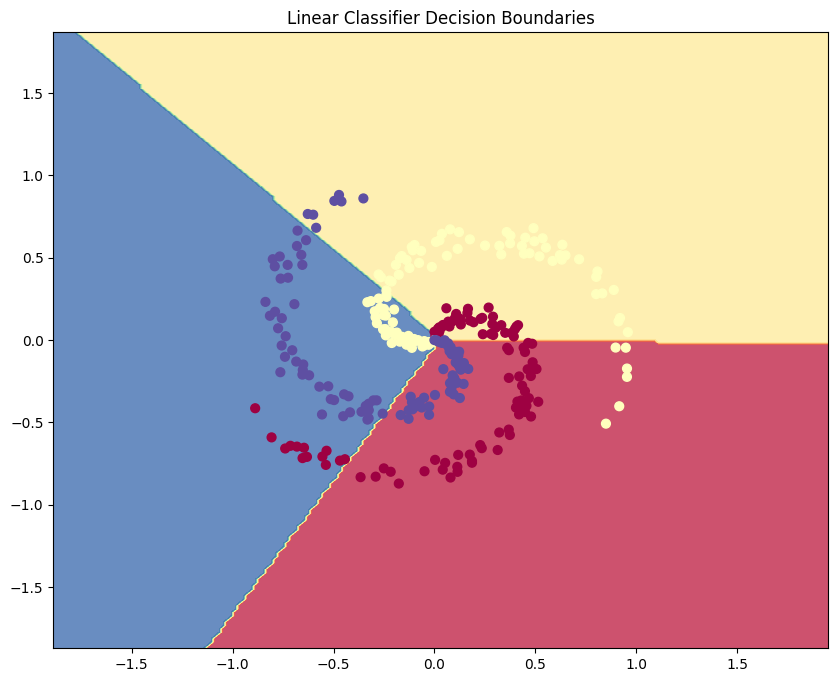

In [15]:
# Plot the resulting classifier
grid_step = 0.02  # Resolution of the decision boundary mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                     np.arange(y_min, y_max, grid_step))
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Linear Classifier Decision Boundaries')
#fig.savefig('spiral_linear.png')

## Neural Network Classifier

Now let's implement a 2-layer neural network to see if we can achieve better results. The architecture is:

**Input (2D) → Hidden Layer (100 units with ReLU) → Output (3 classes with Softmax)**

This network can learn non-linear decision boundaries because:
1. The hidden layer learns useful feature representations of the input
2. The ReLU activation introduces non-linearity (without it, multiple layers would collapse to a single linear transformation)

In [16]:
# Initialize parameters randomly
hidden_size = 100  # size of hidden layer
W = 0.01 * np.random.randn(D, hidden_size)  # First layer weights [2 x 100]
b = np.zeros((1, hidden_size))              # First layer bias [1 x 100]
W2 = 0.01 * np.random.randn(hidden_size, K) # Second layer weights [100 x 3]
b2 = np.zeros((1, K))                       # Second layer bias [1 x 3]

# Hyperparameters
step_size = 1e-0  # Learning rate
num_iterations = 3000

# Gradient descent loop
num_examples = X.shape[0]  # N = 300
for i in range(num_iterations):

    # === Forward pass ===
    # Layer 1: Apply linear transformation and ReLU activation
    hidden_layer = np.maximum(0, np.dot(X, W) + b)  # [N x 100], ReLU activation
    
    # Layer 2: Apply linear transformation to get class scores
    scores = np.dot(hidden_layer, W2) + b2  # [N x K]

    # Compute the class probabilities using Softmax activation
    probs = softmax_numpy(scores)  # [N x K]

    # Compute the loss: average cross-entropy loss
    loss = cross_entropy_loss(probs, y)
    if i % 200 == 0:
        print("iteration {:d}: loss {:.2f}".format(i, loss))

    # === Backward pass ===
    # Compute gradient of loss with respect to scores
    grad_scores = probs.copy()                    # Start with probabilities [N x K]
    grad_scores[range(num_examples), y] -= 1      # Subtract 1 from correct class
    grad_scores /= num_examples                   # Average over all examples

    # Backpropagate the gradient to the parameters
    # First backprop into parameters W2 and b2
    grad_W2 = np.dot(hidden_layer.T, grad_scores)  # [100 x N] * [N x K] = [100 x K]
    grad_b2 = np.sum(grad_scores, axis=0, keepdims=True)  # [1 x K]
    
    # Next backprop into hidden layer
    grad_hidden = np.dot(grad_scores, W2.T)  # [N x K] * [K x 100] = [N x 100]
    
    # Backprop through the ReLU non-linearity
    grad_hidden[hidden_layer <= 0] = 0  # Zero out gradients where ReLU input was <= 0
    
    # Finally backprop into W and b
    grad_W = np.dot(X.T, grad_hidden)  # [D x N] * [N x 100] = [D x 100]
    grad_b = np.sum(grad_hidden, axis=0, keepdims=True)  # [1 x 100]

    # Perform parameter update (gradient descent)
    W += -step_size * grad_W
    b += -step_size * grad_b
    W2 += -step_size * grad_W2
    b2 += -step_size * grad_b2

iteration 0: loss 1.10
iteration 200: loss 0.73
iteration 400: loss 0.36
iteration 600: loss 0.42
iteration 800: loss 0.37
iteration 1000: loss 0.11
iteration 600: loss 0.42
iteration 800: loss 0.37
iteration 1000: loss 0.11
iteration 1200: loss 0.09
iteration 1400: loss 0.07
iteration 1600: loss 0.06
iteration 1200: loss 0.09
iteration 1400: loss 0.07
iteration 1600: loss 0.06
iteration 1800: loss 0.06
iteration 2000: loss 0.05
iteration 2200: loss 0.05
iteration 1800: loss 0.06
iteration 2000: loss 0.05
iteration 2200: loss 0.05
iteration 2400: loss 0.04
iteration 2600: loss 0.04
iteration 2800: loss 0.04
iteration 2400: loss 0.04
iteration 2600: loss 0.04
iteration 2800: loss 0.04


The training accuracy is now:

In [17]:
# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.99


**Much better!** The neural network achieves __99%__ accuracy by learning non-linear decision boundaries that can separate the spiral classes.

Let's visualize the decision boundaries learned by the neural network:

Text(0.5, 1.0, 'Neural Network Decision Boundaries')

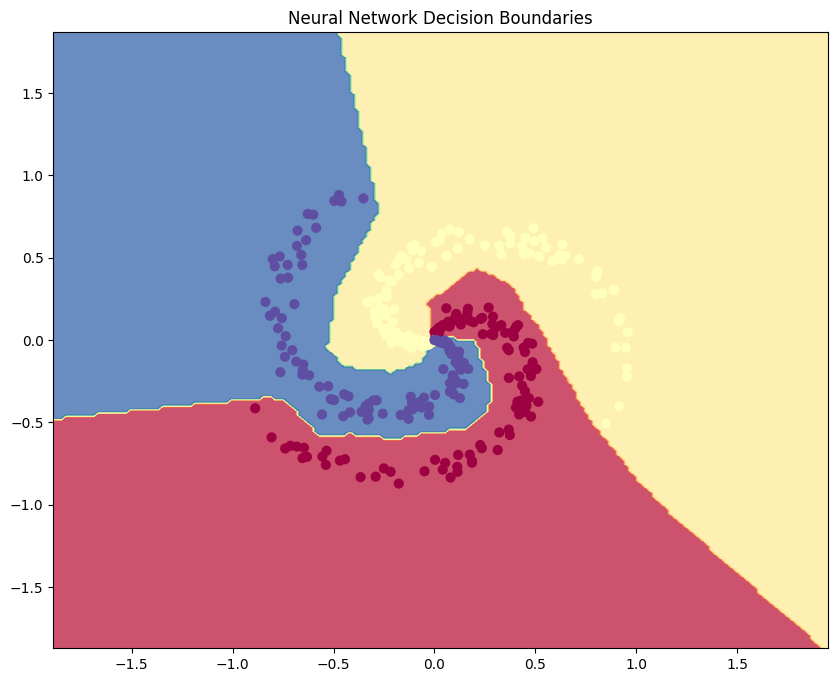

In [18]:
# Plot the resulting classifier
grid_step = 0.02  # Resolution of the decision boundary mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                     np.arange(y_min, y_max, grid_step))

# Evaluate neural network on the mesh grid
hidden = np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b)  # Hidden layer with ReLU
Z = np.dot(hidden, W2) + b2  # Output scores
Z = np.argmax(Z, axis=1)     # Predicted class for each grid point
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Neural Network Decision Boundaries')
#fig.savefig('spiral_net.png')

The neural network's decision boundaries are smooth and curved, perfectly capturing the spiral structure of the data. Compare this to the linear classifier's straight line boundaries!

## Summary

In this notebook, we've implemented a minimal neural network from scratch using only NumPy. Key takeaways:

1. **Linear classifiers** can only learn straight decision boundaries, limiting them to linearly separable problems
2. **Neural networks** with hidden layers and non-linear activations (like ReLU) can learn complex, non-linear decision boundaries
3. **Backpropagation** allows us to compute gradients efficiently through multiple layers using the chain rule
4. Even a simple 2-layer network with 100 hidden units achieves excellent performance (99% accuracy) on the spiral dataset

**Going forward:** While this implementation is useful for understanding the fundamentals, modern deep learning frameworks like PyTorch and TensorFlow provide:
- Automatic differentiation (no need to manually compute gradients)
- GPU acceleration for faster training
- Pre-built layers and optimizers
- Advanced features like batch normalization, dropout, and various architectures

This foundation will help you understand what these frameworks are doing under the hood!